## Notebook 3: Baseline Model Development

After preparing the dataset and building a reusable preprocessing pipeline, the next step is to establish baseline predictive models.

The objective of this notebook is to compare multiple classification algorithms and evaluate their ability to identify loan defaults. Since the dataset is imbalanced, model evaluation extends beyond accuracy and includes precision, recall, F1-score, ROC-AUC, and PR-AUC.

The insights gained in this notebook will guide model selection for probability calibration and business threshold optimization in later stages of RiskLens.

# Import Libaries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,ExtraTreesClassifier,GradientBoostingClassifier

from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    average_precision_score
  )


# Load Processed Datasets

In [ ]:
x_train=pd.read_csv("x_train_processed.csv")
x_test=pd.read_csv("x_test_processed.csv")
y_train=pd.read_csv("y_train.csv").squeeze()
y_test=pd.read_csv("y_test.csv").squeeze()


## Validate Dataset Shapes

Verify that the training and testing datasets were loaded correctly and are ready for model development.

In [ ]:
print("x_train_shape",x_train.shape)
print("x_test_shape",x_test.shape)
print("y_train_shape",y_train.shape)
print("y_test_shape",y_test.shape)


x_train_shape (204277, 31)
x_test_shape (51070, 31)
y_train_shape (204277,)
y_test_shape (51070,)


## Evaluation Framework

A common evaluation framework is created to ensure consistent comparison across all candidate models.

Because loan default prediction is an imbalanced classification problem, multiple metrics will be considered rather than relying solely on accuracy.

In [ ]:
model_results=[]

## Logistic Regression

Logistic Regression serves as the baseline model for binary classification.

Its probabilistic nature makes it particularly valuable in credit risk modeling, where estimating default probability is often more important than producing a simple class prediction.

In [ ]:
log_reg=LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

log_reg.fit(x_train,y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [ ]:
log_reg_pred=log_reg.predict(x_test)
log_reg_pred_proba=log_reg.predict_proba(x_test)[:,1]

In [ ]:
log_reg_results={
    "Model":"Logistic Regression",
    "Accuracy":accuracy_score(y_test,log_reg_pred),
    "Precision":precision_score(y_test,log_reg_pred),
    "Recall":recall_score(y_test,log_reg_pred),
    "F1":f1_score(y_test,log_reg_pred),
    "ROC AUC":roc_auc_score(y_test,log_reg_pred_proba),
    "PR AUC":average_precision_score(y_test,log_reg_pred_proba)
}

model_results.append(log_reg_results)

log_reg_results

{'Model': 'Logistic Regression',
 'Accuracy': 0.6763853534364598,
 'Precision': 0.21950444726810672,
 'Recall': 0.6990389479008599,
 'F1': 0.3340988758612353,
 'ROC AUC': np.float64(0.753178399553392),
 'PR AUC': np.float64(0.31054155518763255)}

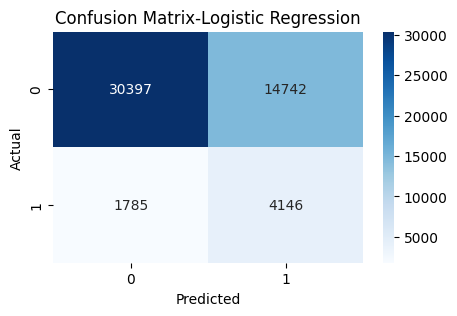

In [ ]:
cm=confusion_matrix(y_test,log_reg_pred)

plt.figure(figsize=(5,3))
sns.heatmap(cm,annot=True,cmap="Blues",fmt="d")
plt.title("Confusion Matrix-Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
print(classification_report(y_test,log_reg_pred))

              precision    recall  f1-score   support

           0       0.94      0.67      0.79     45139
           1       0.22      0.70      0.33      5931

    accuracy                           0.68     51070
   macro avg       0.58      0.69      0.56     51070
weighted avg       0.86      0.68      0.73     51070



## Random Forest

Random Forest is an ensemble learning method that combines multiple decision trees to improve robustness and reduce overfitting.

The model can capture non-linear relationships and feature interactions that may not be detected by Logistic Regression.

In [ ]:
rf_model= RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(x_train,y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1,
                       random_state=42)

In [ ]:
rf_pred=rf_model.predict(x_test)
rf_proba=rf_model.predict_proba(x_test)[:,1]


In [ ]:
rf_results={
    "Model":"Random Forest",
    "Accuracy":accuracy_score(y_test,rf_pred),
    "Precision":precision_score(y_test,rf_pred),
    "Recall":recall_score(y_test,rf_pred),
    "F1":f1_score(y_test,rf_pred),
    "ROC AUC":roc_auc_score(y_test,rf_proba),
    "PR AUC":average_precision_score(y_test,rf_proba)
}

model_results.append(rf_results)

rf_results

{'Model': 'Random Forest',
 'Accuracy': 0.8846876835715685,
 'Precision': 0.71,
 'Recall': 0.011970999831394368,
 'F1': 0.023545017410048084,
 'ROC AUC': np.float64(0.744395812557617),
 'PR AUC': np.float64(0.3041905377415047)}

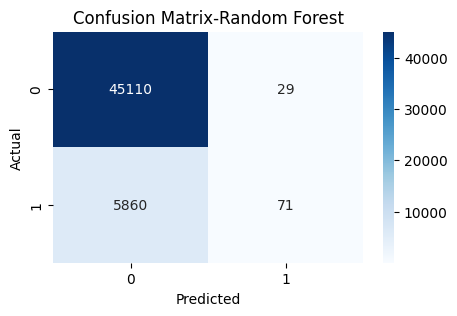

In [ ]:
cm=confusion_matrix(y_test,rf_pred)

plt.figure(figsize=(5,3))
sns.heatmap(cm,annot=True,cmap="Blues",fmt="d")
plt.title("Confusion Matrix-Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
print(classification_report(y_test,rf_pred))

              precision    recall  f1-score   support

           0       0.89      1.00      0.94     45139
           1       0.71      0.01      0.02      5931

    accuracy                           0.88     51070
   macro avg       0.80      0.51      0.48     51070
weighted avg       0.86      0.88      0.83     51070



## Extra Trees Classifier

Extra Trees introduces additional randomness during tree construction, often improving generalization and reducing variance.

This model is evaluated to determine whether increased randomness improves predictive performance.

In [ ]:
extra_trees_model=ExtraTreesClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

extra_trees_model.fit(x_train,y_train)

ExtraTreesClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1,
                     random_state=42)

In [ ]:
extra_trees_pred=extra_trees_model.predict(x_test)
extra_trees_proba=extra_trees_model.predict_proba(x_test)[:,1]

In [ ]:
extra_trees_results={
    "Model":"Extra Trees",
    "Accuracy":accuracy_score(y_test,extra_trees_pred),
    "Precision":precision_score(y_test,extra_trees_pred),
    "Recall":recall_score(y_test,extra_trees_pred),
    "F1":f1_score(y_test,extra_trees_pred),
    "ROC AUC":roc_auc_score(y_test,extra_trees_proba),
    "PR AUC":average_precision_score(y_test,extra_trees_proba)
}

model_results.append(extra_trees_results)

extra_trees_results

{'Model': 'Extra Trees',
 'Accuracy': 0.8840023497160759,
 'Precision': 0.574468085106383,
 'Recall': 0.004552352048558422,
 'F1': 0.009033121445299431,
 'ROC AUC': np.float64(0.7305448855222896),
 'PR AUC': np.float64(0.28047770118349796)}

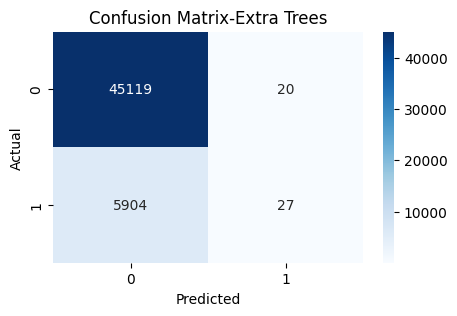

In [ ]:
cm=confusion_matrix(y_test,extra_trees_pred)

plt.figure(figsize=(5,3))
sns.heatmap(cm,annot=True,cmap="Blues",fmt="d")
plt.title("Confusion Matrix-Extra Trees")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
print(classification_report(y_test,extra_trees_pred))

              precision    recall  f1-score   support

           0       0.88      1.00      0.94     45139
           1       0.57      0.00      0.01      5931

    accuracy                           0.88     51070
   macro avg       0.73      0.50      0.47     51070
weighted avg       0.85      0.88      0.83     51070



## Gradient Boosting

Gradient Boosting builds trees sequentially, with each new tree focusing on correcting the errors made by previous trees.

This approach often achieves strong predictive performance in structured tabular datasets such as credit risk data.

In [ ]:
gb_model=GradientBoostingClassifier(
    random_state=42
)
gb_model.fit(x_train,y_train)

GradientBoostingClassifier(random_state=42)

In [ ]:
gb_pred=gb_model.predict(x_test)
gb_proba=gb_model.predict_proba(x_test)[:,1]

In [ ]:
gb_results={
    "Model":"Gradient Boosting",
    "Accuracy":accuracy_score(y_test,gb_pred),
    "Precision":precision_score(y_test,gb_pred),
    "Recall":recall_score(y_test,gb_pred),
    "F1":f1_score(y_test,gb_pred),
    "ROC AUC":roc_auc_score(y_test,gb_proba),
    "PR AUC":average_precision_score(y_test,gb_proba)
}

model_results.append(gb_results)

gb_results

{'Model': 'Gradient Boosting',
 'Accuracy': 0.8861758370863521,
 'Precision': 0.6260683760683761,
 'Recall': 0.049401450008430284,
 'F1': 0.09157680887638693,
 'ROC AUC': np.float64(0.7580078402160226),
 'PR AUC': np.float64(0.3291695187433482)}

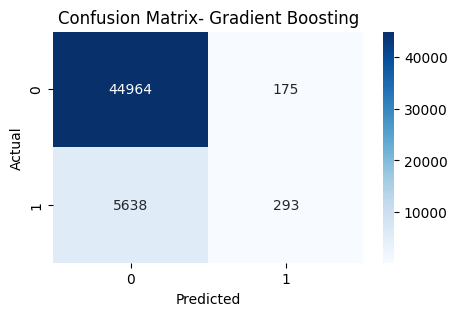

In [ ]:
cm=confusion_matrix(y_test,gb_pred)

plt.figure(figsize=(5,3))
sns.heatmap(cm,annot=True,cmap="Blues",fmt="d")
plt.title("Confusion Matrix- Gradient Boosting")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
print(classification_report(y_test,gb_pred))

              precision    recall  f1-score   support

           0       0.89      1.00      0.94     45139
           1       0.63      0.05      0.09      5931

    accuracy                           0.89     51070
   macro avg       0.76      0.52      0.52     51070
weighted avg       0.86      0.89      0.84     51070



### Why Accuracy Alone Is Not Enough

In credit risk modeling, the cost of missing a defaulter is often significantly higher than incorrectly flagging a safe applicant.

As a result, model evaluation should consider:

- Precision
- Recall
- F1 Score
- ROC-AUC
- PR-AUC

rather than relying solely on accuracy.

This approach provides a more realistic assessment of a model's ability to identify high-risk borrowers.

##  Model Comparison

Aggregate performance metrics from all baseline models to facilitate direct comparison.

The goal is to identify the model that provides the best balance between predictive power and risk detection capability.

In [ ]:
results_df=pd.DataFrame(model_results)
results_df

,Model,Accuracy,Precision,Recall,F1,ROC AUC,PR AUC
0,Logistic Regression,0.676385,0.219504,0.699039,0.334099,0.753178,0.310542
1,Random Forest,0.884688,0.710000,0.011971,0.023545,0.744396,0.304191
2,Extra Trees,0.884002,0.574468,0.004552,0.009033,0.730545,0.280478
3,Gradient Boosting,0.886176,0.626068,0.049401,0.091577,0.758008,0.329170


## Ranking Models by ROC-AUC

ROC-AUC measures a model's ability to distinguish between defaulters and non-defaulters across all classification thresholds.

This metric is particularly useful when probability estimation is important.

In [ ]:
results_df.sort_values(by="ROC AUC",ascending=False)

,Model,Accuracy,Precision,Recall,F1,ROC AUC,PR AUC
3,Gradient Boosting,0.886176,0.626068,0.049401,0.091577,0.758008,0.329170
0,Logistic Regression,0.676385,0.219504,0.699039,0.334099,0.753178,0.310542
1,Random Forest,0.884688,0.710000,0.011971,0.023545,0.744396,0.304191
2,Extra Trees,0.884002,0.574468,0.004552,0.009033,0.730545,0.280478


##Ranking Models by PR-AUC

Precision-Recall AUC is especially informative for imbalanced datasets because it focuses on performance for the minority class.

In RiskLens, identifying actual defaulters is a critical objective, making PR-AUC an important evaluation metric.

In [ ]:
results_df.sort_values(by="PR AUC",ascending=False)

,Model,Accuracy,Precision,Recall,F1,ROC AUC,PR AUC
3,Gradient Boosting,0.886176,0.626068,0.049401,0.091577,0.758008,0.329170
0,Logistic Regression,0.676385,0.219504,0.699039,0.334099,0.753178,0.310542
1,Random Forest,0.884688,0.710000,0.011971,0.023545,0.744396,0.304191
2,Extra Trees,0.884002,0.574468,0.004552,0.009033,0.730545,0.280478


## Visual Performance Comparison

Visualize model performance to better understand differences between candidate algorithms.

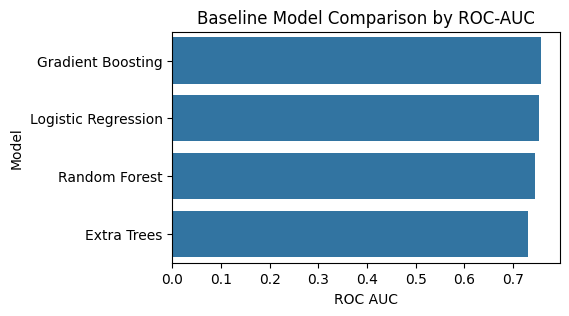

In [ ]:
plt.figure(figsize=(5,3))
sns.barplot(x="ROC AUC",y="Model",data=results_df.sort_values(by="ROC AUC",ascending=False))
plt.title("Baseline Model Comparison by ROC-AUC")
plt.show()

### Model Selection Strategy

The best baseline model is selected primarily using ROC-AUC and PR-AUC rather than accuracy.

The selected model will be carried forward into probability calibration and business threshold optimization, where lending decisions will be driven by estimated default probabilities rather than raw class predictions.

Gradient Boosting achieved the highest ROC-AUC and PR-AUC and is selected as the foundation for probability calibration in Notebook 4

Persist Best Baseline Model:

Save the strongest baseline model for use in probability calibration, threshold optimization, risk segmentation, and explainability analysis.

In [ ]:
results_df.to_csv("baseline_model_results.csv",index=False)

In [ ]:
import joblib
best_baseline_model=gb_model
joblib.dump(best_baseline_model,"best_baseline_model.pkl")


['best_baseline_model.pkl']

## Key Findings

- Multiple baseline models were evaluated using a consistent preprocessing pipeline.
- Accuracy alone was insufficient due to class imbalance.
- ROC-AUC and PR-AUC provided a more reliable assessment of model quality.
- Ensemble-based approaches demonstrated stronger predictive performance than the linear baseline.
- The selected model will serve as the foundation for probability calibration and business threshold optimization in the next notebook.

The focus now shifts from predicting defaults to producing reliable probability estimates that can support lending decisions.